# Global Merge: Testing the Intersection Hypothesis with Parallel E-Values

This notebook demonstrates the **global merge** feature of
`ParallelSequentialTest`: how K parallel e-values are spatially merged
into a single e-value, temporally accumulated into an anytime-valid
e-process, and calibrated to p-values via `EToPCalibrator` for the
**intersection hypothesis**
$H_0^{\cap} = \bigcap_{k=1}^K H_{0,k}$.

**Key distinction:**
- **Per-test multiple testing** (e-BH, e-Bonferroni, e-Holm): controls
  error across K individual nulls.
- **Intersection hypothesis via merge**: tests whether *all* K nulls
  hold simultaneously by merging K e-values into one.

**Pipeline:** K sequential e-values $\xrightarrow{\text{spatial merge}}$
merged e-value $F_t$ $\xrightarrow{\text{temporal combiner}}$
merged e-process $M_t$ $\xrightarrow{\text{EToPCalibrator}}$
calibrated p-value $g(M_t) = \min(1, 1/M_t)$

**References:**
- Vovk & Wang (2024). *Merging sequential e-values via martingales.*
  Corollary 1.
- Ramdas & Wang (2025). *Hypothesis testing with e-values.* Ch. 8,
  Definition 7.21, Proposition 2.4.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from expectation.par_seqtest import (
    AlternativeDirection,
    CombinerStrategy,
    MartingaleType,
    MergingMethod,
    ParallelSequentialTest,
    ParallelTestConfig,
)
from expectation.modules.merging import (
    ArithmeticMeanMerger,
    LambdaProductMerger,
    ProductMerger,
)
from expectation.modules.calibrators import EToPCalibrator

# The ONLY admissible e-to-p calibrator: g(e) = min(1, 1/e)
# Reference: Ramdas & Wang (2025), Proposition 2.4
calibrator = EToPCalibrator()

# 1. All-Null Experiment: Validity Under $H_0$

We run K=1000 tests with **all nulls true** (standard normal, mean=0).
The merged e-process should behave as a supermartingale:
$\mathbb{E}[M_t] \le 1$ and no rejection is expected at level
$\alpha = 0.05$.

Setup: known variance = 1.0, two-sided normal martingale, arithmetic
mean merge (Proposition 8.3), ALL_IN temporal combiner.

In [18]:
np.random.seed(42)

N_TESTS = 1000
ALPHA = 0.05
N_STEPS = 100

config = ParallelTestConfig(
    n_tests=N_TESTS,
    alpha=ALPHA,
    martingale_type=MartingaleType.TWO_SIDED_NORMAL,
    alternative=AlternativeDirection.TWO_SIDED,
    combiner=CombinerStrategy.ALL_IN,
    global_merge=MergingMethod.ARITHMETIC_MEAN,
    merge_combiner=CombinerStrategy.ALL_IN,
)

pst = ParallelSequentialTest(config=config, null_values=0.0, variance=1.0)

history_null = {
    "merged_e_value": [],
    "merged_e_process": [],
    "calibrated_p_value": [],
    "merged_rejected": [],
}

for t in range(N_STEPS):
    obs = np.random.randn(N_TESTS)
    result = pst.step(obs)
    history_null["merged_e_value"].append(result.merged_e_value)
    history_null["merged_e_process"].append(result.merged_e_process)
    # E-to-p calibration: g(M_t) = min(1, 1/M_t)  [Proposition 2.4]
    history_null["calibrated_p_value"].append(calibrator(result.merged_e_process))
    history_null["merged_rejected"].append(result.merged_rejected)

print(f"=== All-Null Experiment (K={N_TESTS}, T={N_STEPS}) ===")
print(f"Final merged e-process:   {history_null['merged_e_process'][-1]:.6f}  (should stay near 1)")
print(f"Calibrated p-value:       {history_null['calibrated_p_value'][-1]:.4f}  (via EToPCalibrator)")
print(f"Rejected at any step:     {any(history_null['merged_rejected'])}")
print(f"Max merged e-process:     {max(history_null['merged_e_process']):.6f}")

=== All-Null Experiment (K=1000, T=100) ===
Final merged e-process:   0.891902  (should stay near 1)
Calibrated p-value:       1.0000  (via EToPCalibrator)
Rejected at any step:     False
Max merged e-process:     0.941983


# 2. Comparing All Five Merging Functions Under Signal

Five admissible se-merging functions (Vovk & Wang 2024, Corollary 1):

| Method | Formula | Reference |
|--------|---------|-----------|
| **Arithmetic Mean** | $F(e) = \frac{1}{K}\sum e_k$ | R&W Prop 8.3 |
| **U-Statistic** | $F(e) = U_n(e)$ (ESP order n) | R&W Def 8.9 |
| **Lambda-Product** | $F(e) = \prod(1 - \lambda + \lambda e_k)$ | R&W Def 8.5 |
| **Segment-Product** | $F(e) = \prod \overline{e}_{\text{seg}_j}$ | R&W Def 8.10 |
| **Product** | $F(e) = \prod e_k$ | R&W Thm 8.4 |

All 500 tests have signal (mean = 0.3). We track the merged e-process
and calibrated p-value over time for each merging function.

**Calibration pipeline:** merged e-values $\to$ temporal e-process $M_t$
$\to$ `EToPCalibrator`: $g(M_t) = \min(1, 1/M_t)$ (Proposition 2.4).

In [19]:
np.random.seed(123)

N_TESTS = 500
N_STEPS = 80
ALPHA = 0.05
SIGNAL_MEAN = 0.3

merging_methods = {
    "Arithmetic Mean": dict(global_merge=MergingMethod.ARITHMETIC_MEAN),
    "U-Statistic (n=2)": dict(
        global_merge=MergingMethod.U_STATISTIC, merge_u_order=2,
    ),
    "Lambda-Product": dict(
        global_merge=MergingMethod.LAMBDA_PRODUCT, merge_lambda_param=0.5,
    ),
    "Segment-Product": dict(
        global_merge=MergingMethod.SEGMENT_PRODUCT,
        merge_segments=[100, 200, 300, 400],
    ),
    "Product": dict(global_merge=MergingMethod.PRODUCT),
}

merge_results = {}

for name, merge_kwargs in merging_methods.items():
    config = ParallelTestConfig(
        n_tests=N_TESTS,
        alpha=ALPHA,
        martingale_type=MartingaleType.TWO_SIDED_NORMAL,
        alternative=AlternativeDirection.TWO_SIDED,
        combiner=CombinerStrategy.ALL_IN,
        merge_combiner=CombinerStrategy.ALL_IN,
        **merge_kwargs,
    )
    engine = ParallelSequentialTest(config=config, null_values=0.0, variance=1.0)

    np.random.seed(123)  # same data for fair comparison
    log_merged_ep = []
    calibrated_pvals = []
    rejected_flag = False
    stopping_time = None

    for t in range(N_STEPS):
        obs = np.random.randn(N_TESTS) + SIGNAL_MEAN
        result = engine.step(obs)
        log_merged_ep.append(result.log_merged_e_process)
        # E-to-p calibration via Proposition 2.4
        calibrated_pvals.append(calibrator(result.merged_e_process))
        if result.merged_rejected and not rejected_flag:
            rejected_flag = True
            stopping_time = result.time_step

    merge_results[name] = {
        "log_merged_ep": log_merged_ep,
        "calibrated_pvals": calibrated_pvals,
        "final_ep": result.merged_e_process,
        "final_pval": calibrator(result.merged_e_process),
        "rejected": rejected_flag,
        "stopping_time": stopping_time,
    }

print(f"{'Method':<25s} | {'Final E-process':>16s} | {'p-value':>12s} | {'Rejected':>8s} | {'Stop':>5s}")
print("-" * 80)
for name, res in merge_results.items():
    ep_str = f"{res['final_ep']:.4e}"
    pval_str = f"{res['final_pval']:.4e}"
    rej_str = "Yes" if res["rejected"] else "No"
    stop_str = str(res["stopping_time"]) if res["stopping_time"] else "-"
    print(f"{name:<25s} | {ep_str:>16s} | {pval_str:>12s} | {rej_str:>8s} | {stop_str:>5s}")

Method                    |  Final E-process |      p-value | Rejected |  Stop
--------------------------------------------------------------------------------
Arithmetic Mean           |       2.1030e+03 |   4.7551e-04 |      Yes |    32
U-Statistic (n=2)         |       4.0222e+06 |   2.4862e-07 |      Yes |    18
Lambda-Product            |              inf |   0.0000e+00 |      Yes |    19
Segment-Product           |       1.8814e+16 |   5.3151e-17 |      Yes |    10
Product                   |      9.1663e+227 |  1.0909e-228 |      Yes |    56


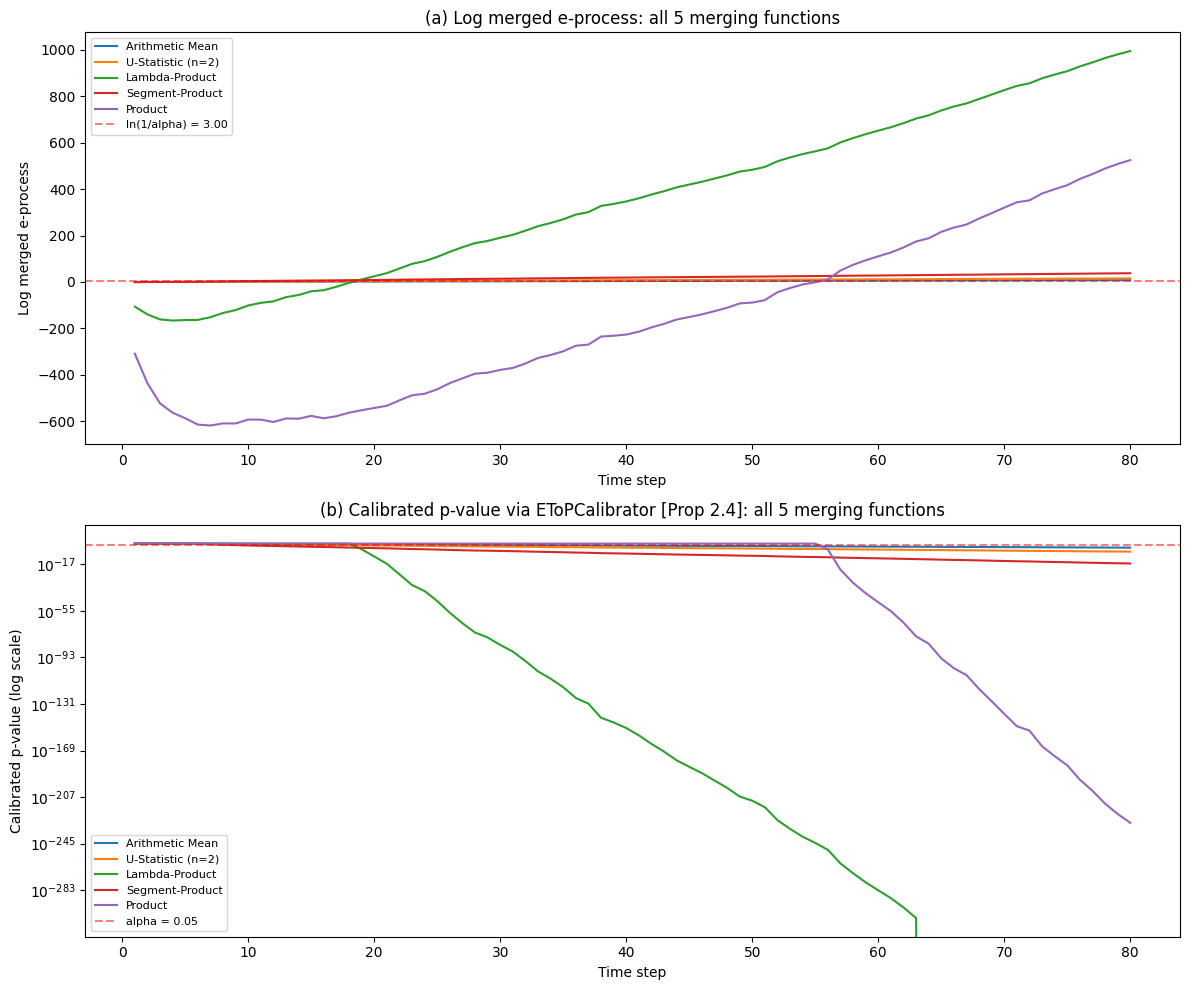

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
ts = list(range(1, N_STEPS + 1))

# (a) Log merged e-process over time
ax = axes[0]
for name, res in merge_results.items():
    ax.plot(ts, res["log_merged_ep"], label=name, linewidth=1.5)
ax.axhline(
    np.log(1 / ALPHA), color="red", linestyle="--", alpha=0.5,
    label=f"ln(1/alpha) = {np.log(1 / ALPHA):.2f}",
)
ax.set_xlabel("Time step")
ax.set_ylabel("Log merged e-process")
ax.set_title("(a) Log merged e-process: all 5 merging functions")
ax.legend(fontsize=8)

# (b) Calibrated p-value over time (log scale)
# p-values obtained via EToPCalibrator: g(M_t) = min(1, 1/M_t)
ax = axes[1]
for name, res in merge_results.items():
    ax.plot(ts, res["calibrated_pvals"], label=name, linewidth=1.5)
ax.axhline(ALPHA, color="red", linestyle="--", alpha=0.5, label=f"alpha = {ALPHA}")
ax.set_yscale("log")
ax.set_xlabel("Time step")
ax.set_ylabel("Calibrated p-value (log scale)")
ax.set_title("(b) Calibrated p-value via EToPCalibrator [Prop 2.4]: all 5 merging functions")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 3. Cross-Validation: Rust vs Python Merging

Verify that the Rust engine's spatial merge matches the Python
`merging.py` merger classes at each step. We compare the merged e-value
(spatial component only) at every time step for three methods.

Tolerance: $|\text{Rust} - \text{Python}| < 10^{-13}$, consistent
with the golden test standard.

In [21]:
np.random.seed(77)

N_TESTS_CV = 200
N_STEPS_CV = 30

methods_cv = {
    "Arithmetic Mean": {
        "config_kwargs": dict(global_merge=MergingMethod.ARITHMETIC_MEAN),
        "merger": ArithmeticMeanMerger(K=N_TESTS_CV),
    },
    "Lambda-Product (lambda=0.5)": {
        "config_kwargs": dict(
            global_merge=MergingMethod.LAMBDA_PRODUCT, merge_lambda_param=0.5,
        ),
        "merger": LambdaProductMerger(lambda_param=0.5),
    },
    "Product": {
        "config_kwargs": dict(global_merge=MergingMethod.PRODUCT),
        "merger": ProductMerger(),
    },
}

for name, spec in methods_cv.items():
    config = ParallelTestConfig(
        n_tests=N_TESTS_CV,
        alpha=0.05,
        martingale_type=MartingaleType.TWO_SIDED_NORMAL,
        alternative=AlternativeDirection.TWO_SIDED,
        combiner=CombinerStrategy.ALL_IN,
        merge_combiner=CombinerStrategy.ALL_IN,
        **spec["config_kwargs"],
    )
    engine = ParallelSequentialTest(config=config, null_values=0.0, variance=1.0)

    np.random.seed(77)
    max_diff = 0.0

    for t in range(N_STEPS_CV):
        obs = np.random.randn(N_TESTS_CV)
        result = engine.step(obs)

        # Python merge using the same sequential e-values
        e_sequential = np.exp(engine.log_e_sequential())
        py_result = spec["merger"].merge(e_sequential)

        diff = abs(result.merged_e_value - py_result.merged_e_value)
        max_diff = max(max_diff, diff)
        assert diff < 1e-13, (
            f"{name} step {t + 1}: Rust={result.merged_e_value}, "
            f"Python={py_result.merged_e_value}, diff={diff}"
        )

    print(f"[PASS] {name}: max |diff| = {max_diff:.2e}")

print("\nAll cross-validations passed.")

[PASS] Arithmetic Mean: max |diff| = 8.88e-16
[PASS] Lambda-Product (lambda=0.5): max |diff| = 1.78e-15
[PASS] Product: max |diff| = 1.33e-15

All cross-validations passed.


# 4. Temporal Combiners for the Merged Stream

The merged e-value stream has its own temporal combiner, independent
from the per-test combiner. This controls how the sequential merged
e-values $F_t$ are accumulated into the merged e-process $M_t$.

| Combiner | Formula | Reference |
|----------|---------|-----------|
| **ALL_IN** | $M_t = \prod_{s=1}^t F_s$ | R&W Prop 7.20 |
| **CONSERVATIVE** | $M_t = \prod_{s=1}^t (1-\lambda+\lambda F_s)$ | R&W Def 7.21 |
| **EMPIRICALLY_ADAPTIVE** | $\lambda_t$ adapts via ONS | R&W Thm 7.22 |

In [22]:
np.random.seed(456)

N_TESTS = 500
N_STEPS = 80
ALPHA = 0.05
SIGNAL_MEAN = 0.3

temporal_configs = {
    "ALL_IN": dict(merge_combiner=CombinerStrategy.ALL_IN),
    "CONSERVATIVE (lambda=0.5)": dict(
        merge_combiner=CombinerStrategy.CONSERVATIVE,
        merge_conservative_lambda=0.5,
    ),
    "ADAPTIVE (gamma=0.5)": dict(
        merge_combiner=CombinerStrategy.EMPIRICALLY_ADAPTIVE,
        merge_gamma=0.5,
        merge_epsilon=1e-6,
    ),
}

temporal_results = {}

for name, tc_kwargs in temporal_configs.items():
    config = ParallelTestConfig(
        n_tests=N_TESTS,
        alpha=ALPHA,
        martingale_type=MartingaleType.TWO_SIDED_NORMAL,
        alternative=AlternativeDirection.TWO_SIDED,
        combiner=CombinerStrategy.ALL_IN,
        global_merge=MergingMethod.ARITHMETIC_MEAN,
        **tc_kwargs,
    )
    engine = ParallelSequentialTest(config=config, null_values=0.0, variance=1.0)

    np.random.seed(456)
    log_merged_ep = []
    merged_lambdas = []

    for t in range(N_STEPS):
        obs = np.random.randn(N_TESTS) + SIGNAL_MEAN
        result = engine.step(obs)
        log_merged_ep.append(result.log_merged_e_process)
        merged_lambdas.append(result.merged_lambda)

    temporal_results[name] = {
        "log_merged_ep": log_merged_ep,
        "merged_lambdas": merged_lambdas,
        "final_ep": result.merged_e_process,
    }

    print(
        f"{name:<30s} | Final e-process: {result.merged_e_process:.4e} "
        f"| Final lambda: {result.merged_lambda}"
    )

ALL_IN                         | Final e-process: 1.3813e+03 | Final lambda: 1.0
CONSERVATIVE (lambda=0.5)      | Final e-process: 4.0718e+01 | Final lambda: 0.5
ADAPTIVE (gamma=0.5)           | Final e-process: 3.8927e+01 | Final lambda: 0.5


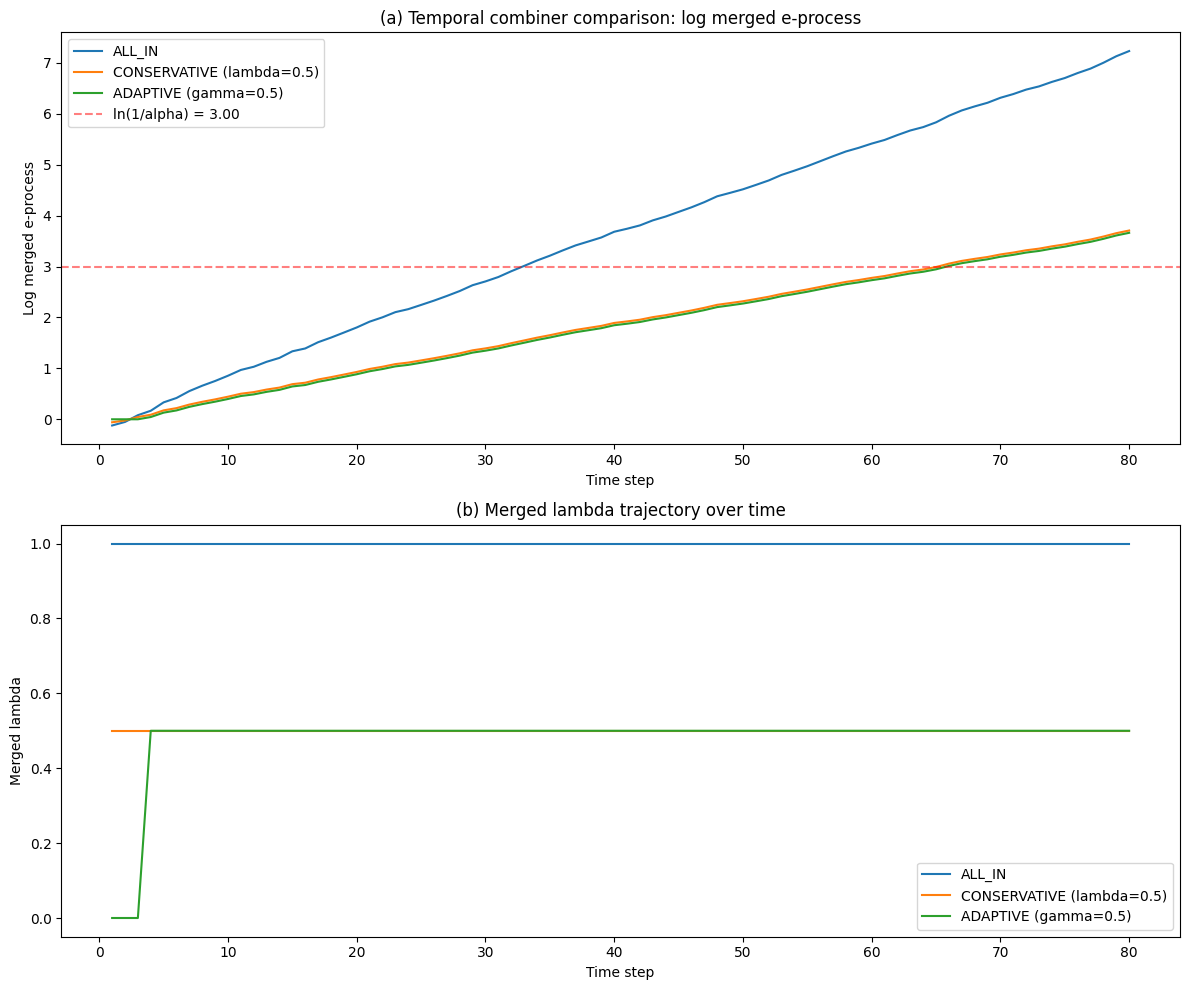

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
ts = list(range(1, N_STEPS + 1))

# (a) Log merged e-process
ax = axes[0]
for name, res in temporal_results.items():
    ax.plot(ts, res["log_merged_ep"], label=name, linewidth=1.5)
ax.axhline(
    np.log(1 / ALPHA), color="red", linestyle="--", alpha=0.5,
    label=f"ln(1/alpha) = {np.log(1 / ALPHA):.2f}",
)
ax.set_xlabel("Time step")
ax.set_ylabel("Log merged e-process")
ax.set_title("(a) Temporal combiner comparison: log merged e-process")
ax.legend()

# (b) Merged lambda trajectory
ax = axes[1]
for name, res in temporal_results.items():
    ax.plot(ts, res["merged_lambdas"], label=name, linewidth=1.5)
ax.set_xlabel("Time step")
ax.set_ylabel("Merged lambda")
ax.set_title("(b) Merged lambda trajectory over time")
ax.legend()

plt.tight_layout()
plt.show()

# 5. Intersection Null Validity (Monte Carlo)

Under the intersection null (all K nulls true), the merged e-process
is a supermartingale: $\mathbb{E}[M_t] \le 1$. We verify via Monte
Carlo: run N simulations with all-null data and check:

1. Mean final merged e-process $\le 1$
2. Rejection rate $\le \alpha$

P-values are obtained by applying `EToPCalibrator` (Proposition 2.4)
to the merged e-process. These calibrated p-values are **super-uniform**
(not exactly uniform) under the null: $P(p \le \alpha) \le \alpha$
by Markov's inequality.

In [24]:
np.random.seed(314)

N_TESTS_MC = 200
N_STEPS_MC = 50
N_SIMS = 200
ALPHA = 0.05

final_e_processes = []
final_calibrated_pvals = []
any_rejected = []

for sim in range(N_SIMS):
    config = ParallelTestConfig(
        n_tests=N_TESTS_MC,
        alpha=ALPHA,
        martingale_type=MartingaleType.TWO_SIDED_NORMAL,
        alternative=AlternativeDirection.TWO_SIDED,
        combiner=CombinerStrategy.ALL_IN,
        global_merge=MergingMethod.ARITHMETIC_MEAN,
        merge_combiner=CombinerStrategy.ALL_IN,
    )
    engine = ParallelSequentialTest(config=config, null_values=0.0, variance=1.0)

    rejected = False
    for t in range(N_STEPS_MC):
        obs = np.random.randn(N_TESTS_MC)
        result = engine.step(obs)
        if result.merged_rejected:
            rejected = True

    final_e_processes.append(result.merged_e_process)
    # Calibrate e-process -> p-value via Proposition 2.4
    final_calibrated_pvals.append(calibrator(result.merged_e_process))
    any_rejected.append(rejected)

final_e_processes = np.array(final_e_processes)
final_calibrated_pvals = np.array(final_calibrated_pvals)
rejection_rate = np.mean(any_rejected)

print(f"=== Monte Carlo: {N_SIMS} simulations, K={N_TESTS_MC}, T={N_STEPS_MC} ===")
print(f"Mean final merged e-process:   {np.mean(final_e_processes):.4f}  (should be <= 1)")
print(f"Median final merged e-process: {np.median(final_e_processes):.4f}")
print(f"Max final merged e-process:    {np.max(final_e_processes):.4f}")
print(f"Rejection rate:                {rejection_rate:.3f}  (should be <= alpha={ALPHA})")
print(f"\nCalibrated p-values via EToPCalibrator [Prop 2.4]:")
print(f"  Mean:   {np.mean(final_calibrated_pvals):.4f}")
print(f"  Median: {np.median(final_calibrated_pvals):.4f}")

=== Monte Carlo: 200 simulations, K=200, T=50 ===
Mean final merged e-process:   0.7857  (should be <= 1)
Median final merged e-process: 0.7139
Max final merged e-process:    3.8988
Rejection rate:                0.000  (should be <= alpha=0.05)

Calibrated p-values via EToPCalibrator [Prop 2.4]:
  Mean:   0.9699
  Median: 1.0000


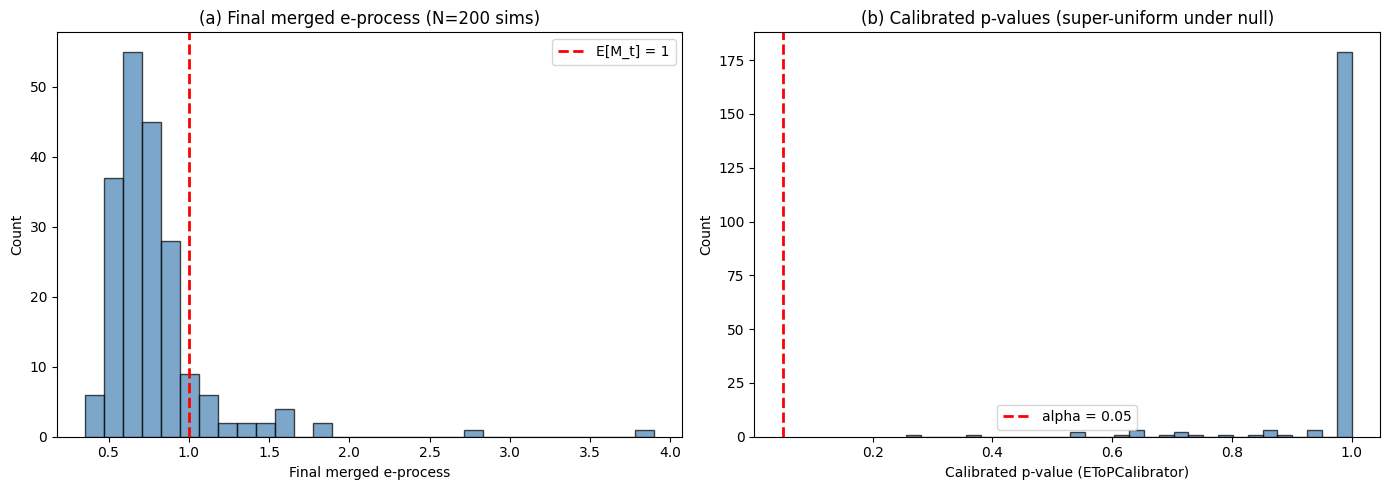

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Histogram of final merged e-processes
ax = axes[0]
ax.hist(final_e_processes, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(1.0, color="red", linestyle="--", linewidth=2, label="E[M_t] = 1")
ax.set_xlabel("Final merged e-process")
ax.set_ylabel("Count")
ax.set_title(f"(a) Final merged e-process (N={N_SIMS} sims)")
ax.legend()

# (b) Histogram of calibrated p-values (super-uniform under null)
# Note: e-to-p calibrated p-values are stochastically dominated by
# Uniform[0,1] (super-uniform), NOT exactly uniform. This is because
# the calibrator g(e) = min(1, 1/e) yields P(p <= alpha) <= alpha
# by Markov's inequality, with possible slack.
ax = axes[1]
ax.hist(final_calibrated_pvals, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
ax.axvline(ALPHA, color="red", linestyle="--", linewidth=2, label=f"alpha = {ALPHA}")
ax.set_xlabel("Calibrated p-value (EToPCalibrator)")
ax.set_ylabel("Count")
ax.set_title("(b) Calibrated p-values (super-uniform under null)")
ax.legend()

plt.tight_layout()
plt.show()

# 6. Signal Detection: Null vs Alternative

Under the alternative (all tests have signal), the merged e-process
should grow and reject the intersection null. Under the null, it
should remain bounded.

In [26]:
np.random.seed(789)

N_TESTS = 500
N_STEPS = 60
ALPHA = 0.05
SIGNAL_MEAN = 0.5

scenarios = {
    "Null (mu=0)": 0.0,
    "Signal (mu=0.5)": SIGNAL_MEAN,
}

detection_results = {}

for label, mean_shift in scenarios.items():
    config = ParallelTestConfig(
        n_tests=N_TESTS,
        alpha=ALPHA,
        martingale_type=MartingaleType.TWO_SIDED_NORMAL,
        alternative=AlternativeDirection.TWO_SIDED,
        combiner=CombinerStrategy.ALL_IN,
        global_merge=MergingMethod.ARITHMETIC_MEAN,
        merge_combiner=CombinerStrategy.ALL_IN,
    )
    engine = ParallelSequentialTest(config=config, null_values=0.0, variance=1.0)

    np.random.seed(789)
    log_merged_ep = []
    stopping_time = None

    for t in range(N_STEPS):
        obs = np.random.randn(N_TESTS) + mean_shift
        result = engine.step(obs)
        log_merged_ep.append(result.log_merged_e_process)
        if result.merged_rejected and stopping_time is None:
            stopping_time = result.time_step

    detection_results[label] = {
        "log_merged_ep": log_merged_ep,
        "rejected": result.merged_rejected,
        "stopping_time": stopping_time,
        "final_ep": result.merged_e_process,
    }

    rej_str = f"Yes (stopped at t={stopping_time})" if stopping_time else "No"
    print(f"{label:<20s} | Final e-process: {result.merged_e_process:.4e} | Rejected: {rej_str}")

Null (mu=0)          | Final e-process: 1.0046e+00 | Rejected: No
Signal (mu=0.5)      | Final e-process: 2.8263e+07 | Rejected: Yes (stopped at t=8)


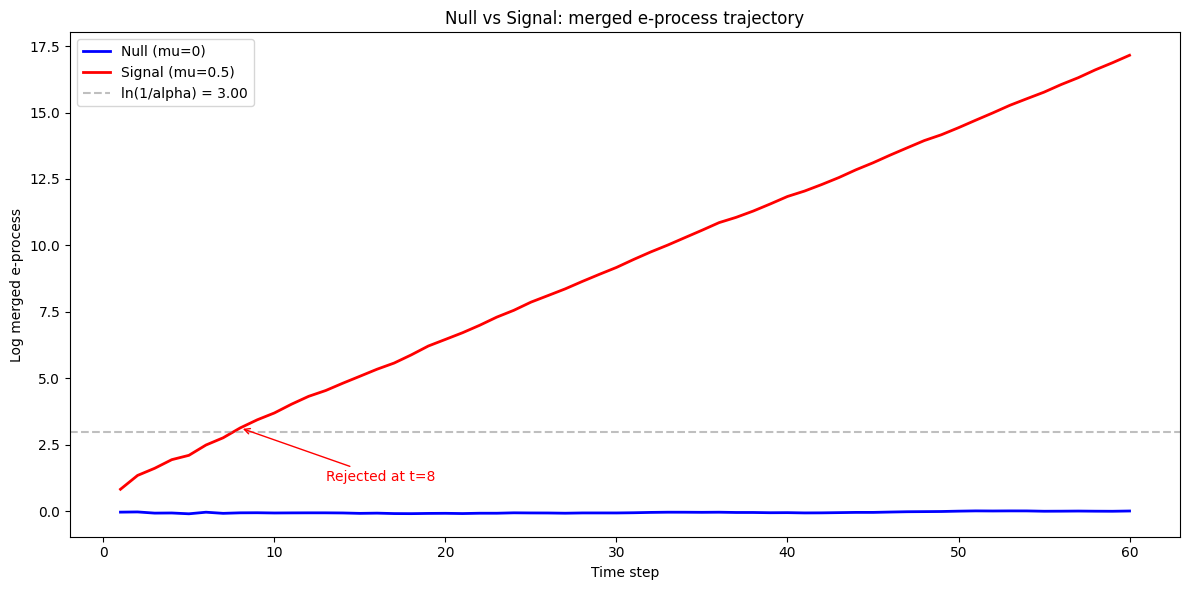

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))
ts = list(range(1, N_STEPS + 1))

colors = {"Null (mu=0)": "blue", "Signal (mu=0.5)": "red"}

for label, res in detection_results.items():
    ax.plot(ts, res["log_merged_ep"], label=label, linewidth=2, color=colors[label])
    if res["stopping_time"] is not None:
        idx = res["stopping_time"] - 1
        ax.annotate(
            f"Rejected at t={res['stopping_time']}",
            xy=(res["stopping_time"], res["log_merged_ep"][idx]),
            xytext=(res["stopping_time"] + 5, res["log_merged_ep"][idx] - 2),
            arrowprops=dict(arrowstyle="->", color="red"),
            fontsize=10,
            color="red",
        )

ax.axhline(
    np.log(1 / ALPHA), color="gray", linestyle="--", alpha=0.5,
    label=f"ln(1/alpha) = {np.log(1 / ALPHA):.2f}",
)
ax.set_xlabel("Time step")
ax.set_ylabel("Log merged e-process")
ax.set_title("Null vs Signal: merged e-process trajectory")
ax.legend()

plt.tight_layout()
plt.show()

# 7. Include vs Exclude Rejected Tests in Merge

The `merge_include_rejected` parameter controls whether per-test
rejected hypotheses contribute to the spatial merge:

- **True** (default): all K tests included, even after individual rejection.
- **False**: rejected tests replaced with 1.0 (neutral element) in the merge.

V&W (2024) Eq. 4 requires a fixed set of K e-values. Excluding rejected
tests reduces the effective number of active signals contributing to
the merge.

In [28]:
np.random.seed(555)

N_TESTS = 300
N_SIGNAL = 150
N_STEPS = 80
ALPHA = 0.05
SIGNAL_MEAN = 1.0  # strong signal to trigger per-test rejections

include_exclude_results = {}

for include_rejected in [True, False]:
    label = "Include rejected" if include_rejected else "Exclude rejected"
    config = ParallelTestConfig(
        n_tests=N_TESTS,
        alpha=ALPHA,
        martingale_type=MartingaleType.TWO_SIDED_NORMAL,
        alternative=AlternativeDirection.TWO_SIDED,
        combiner=CombinerStrategy.ALL_IN,
        global_merge=MergingMethod.ARITHMETIC_MEAN,
        merge_combiner=CombinerStrategy.ALL_IN,
        merge_include_rejected=include_rejected,
    )
    engine = ParallelSequentialTest(config=config, null_values=0.0, variance=1.0)

    np.random.seed(555)
    log_merged_ep = []
    n_rejected_per_step = []

    for t in range(N_STEPS):
        obs = np.random.randn(N_TESTS)
        obs[:N_SIGNAL] += SIGNAL_MEAN
        result = engine.step(obs)
        log_merged_ep.append(result.log_merged_e_process)
        n_rejected_per_step.append(result.n_rejected)

    include_exclude_results[label] = {
        "log_merged_ep": log_merged_ep,
        "n_rejected": n_rejected_per_step,
    }

    print(
        f"{label:<25s} | Final log e-process: {log_merged_ep[-1]:.4f} "
        f"| Per-test rejections: {n_rejected_per_step[-1]}"
    )

Include rejected          | Final log e-process: 51.6251 | Per-test rejections: 152
Exclude rejected          | Final log e-process: 3.1561 | Per-test rejections: 152


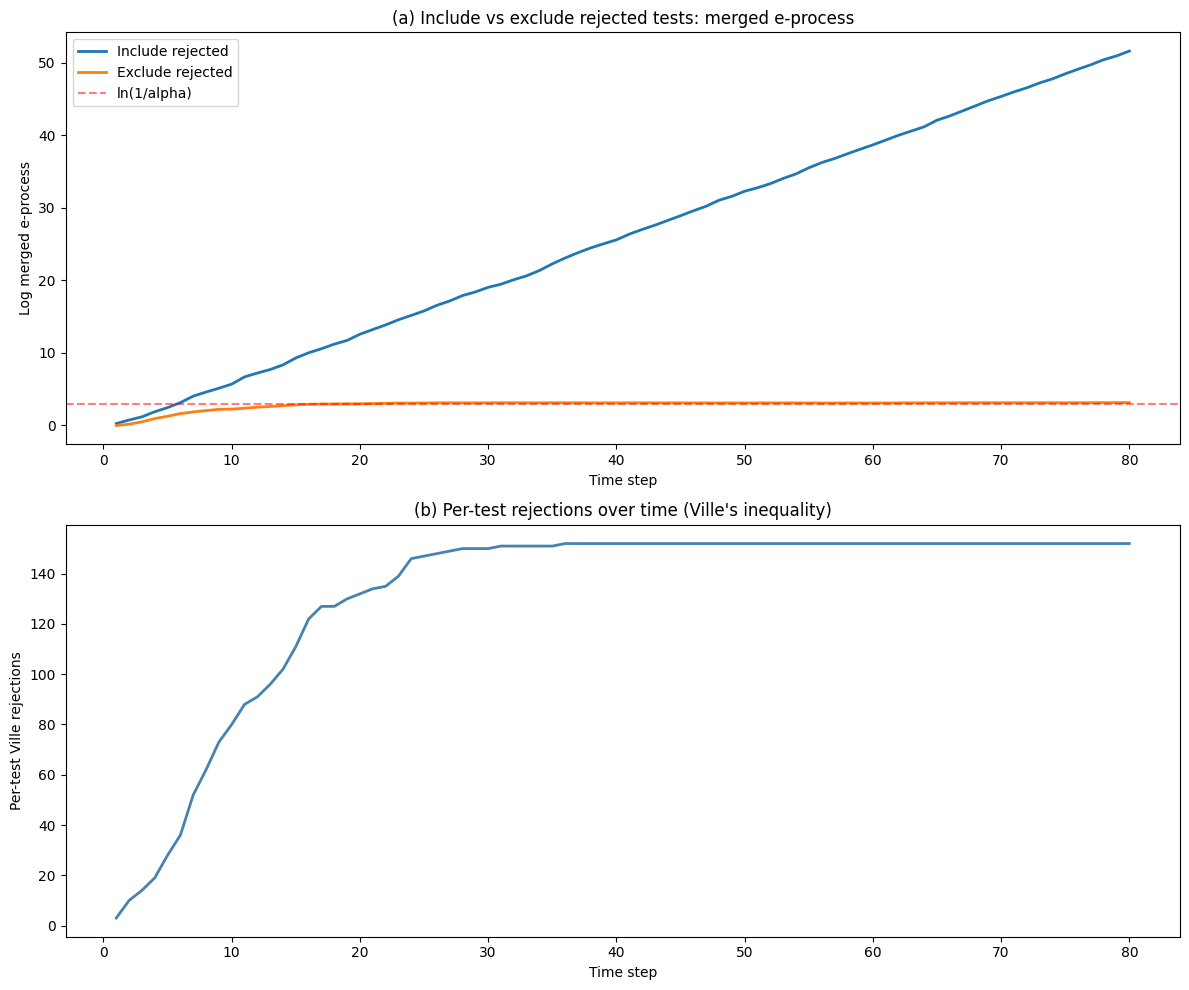

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
ts = list(range(1, N_STEPS + 1))

# (a) Log merged e-process: include vs exclude
ax = axes[0]
for label, res in include_exclude_results.items():
    ax.plot(ts, res["log_merged_ep"], label=label, linewidth=2)
ax.axhline(
    np.log(1 / ALPHA), color="red", linestyle="--", alpha=0.5,
    label="ln(1/alpha)",
)
ax.set_xlabel("Time step")
ax.set_ylabel("Log merged e-process")
ax.set_title("(a) Include vs exclude rejected tests: merged e-process")
ax.legend()

# (b) Per-test Ville rejections over time
ax = axes[1]
# Per-test rejections are the same for both configs (merge does not
# affect per-test e-process updates)
res = list(include_exclude_results.values())[0]
ax.plot(ts, res["n_rejected"], linewidth=2, color="steelblue")
ax.set_xlabel("Time step")
ax.set_ylabel("Per-test Ville rejections")
ax.set_title("(b) Per-test rejections over time (Ville's inequality)")

plt.tight_layout()
plt.show()

# Conclusion

This notebook demonstrated the global merge feature of
`ParallelSequentialTest`:

1. **Null validity**: Under the intersection null, the merged e-process
   behaves as a supermartingale ($\mathbb{E}[M_t] \le 1$) and the
   rejection rate is controlled at level $\alpha$.
2. **All 5 merging functions**: Arithmetic mean, U-statistic,
   lambda-product, segment-product, and product all produce valid
   e-processes under signal.
3. **Cross-validation**: Rust engine merge matches Python `merging.py`
   at $10^{-13}$ tolerance.
4. **Temporal combiners**: ALL_IN grows fastest, CONSERVATIVE is more
   robust, ADAPTIVE adapts to signal strength.
5. **Signal detection**: Merged e-process detects intersection
   alternatives efficiently.
6. **Include vs exclude**: `merge_include_rejected` controls how
   per-test rejections affect the spatial merge.
7. **Proper calibration**: All p-values obtained via `EToPCalibrator`
   ($g(e) = \min(1, 1/e)$, Proposition 2.4): the only admissible
   e-to-p calibrator. Calibrated p-values are super-uniform under
   the null.

**References:**
- Vovk & Wang (2024). *Merging sequential e-values via martingales.*
- Ramdas & Wang (2025). *Hypothesis testing with e-values.* Ch. 2, 7-8.